In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
import zipfile, io, urllib.request

resp = urllib.request.urlopen(url)
zf = zipfile.ZipFile(io.BytesIO(resp.read()))
df = pd.read_csv(zf.open('bank-additional/bank-additional-full.csv'), sep=';')

print(f"Shape: {df.shape}")
df.head()


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric features:", numeric_cols)
print("\nCategorical features:", categorical_cols)

# Numeric distributions: min, max, mean, std, skewness
numeric_stats = df[numeric_cols].describe().T
numeric_stats['skewness'] = df[numeric_cols].skew()
print("\n--- Numeric Feature Statistics ---")
numeric_stats


Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- Numeric Feature Statistics ---


,count,mean,std,min,25%,50%,75%,max,skewness
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000,0.784697
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000,3.263141
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000,4.762507
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000,-4.922190
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000,3.832042
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400,-0.724096
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767,-0.230888
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900,0.303180
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045,-0.709188
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100,-1.044262


In [9]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

# Check for 'unknown' values across categorical features
print("\n--- Unknown Value Counts ---")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknowns ({unknown_count/len(df)*100:.2f}%)")

# Check for actual NaN values
print(f"\nTotal NaN values: {df.isnull().sum().sum()}")



--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      9

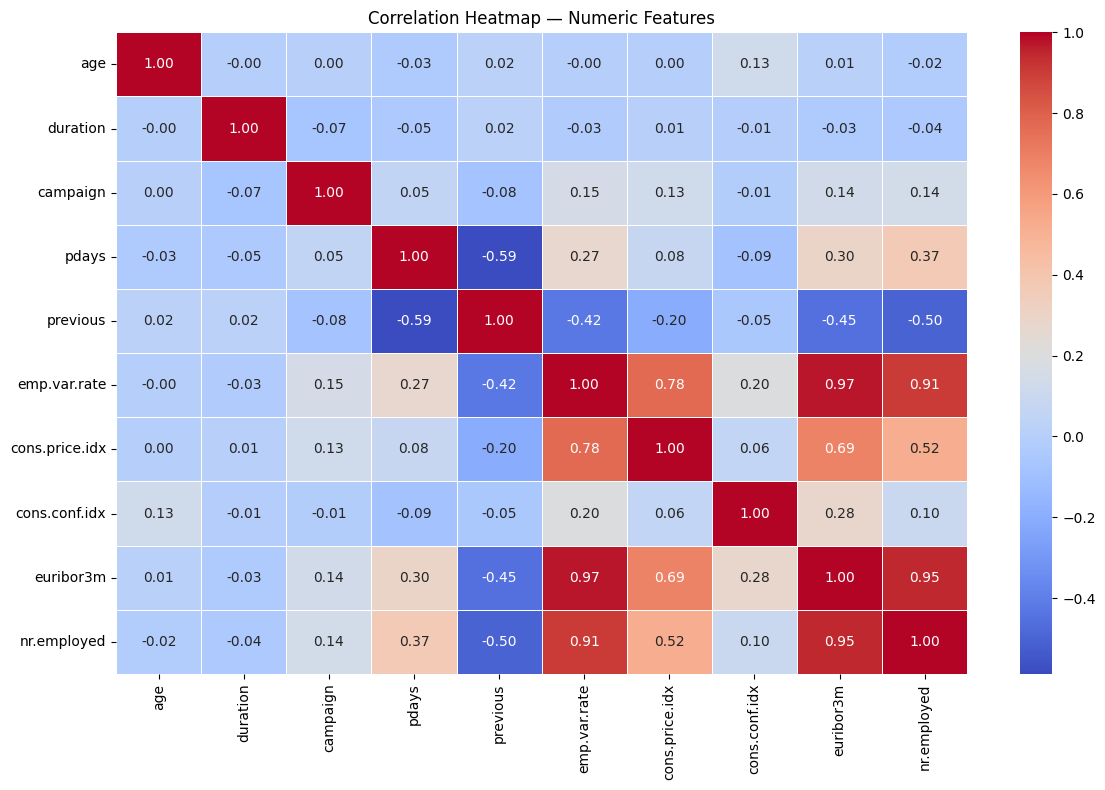

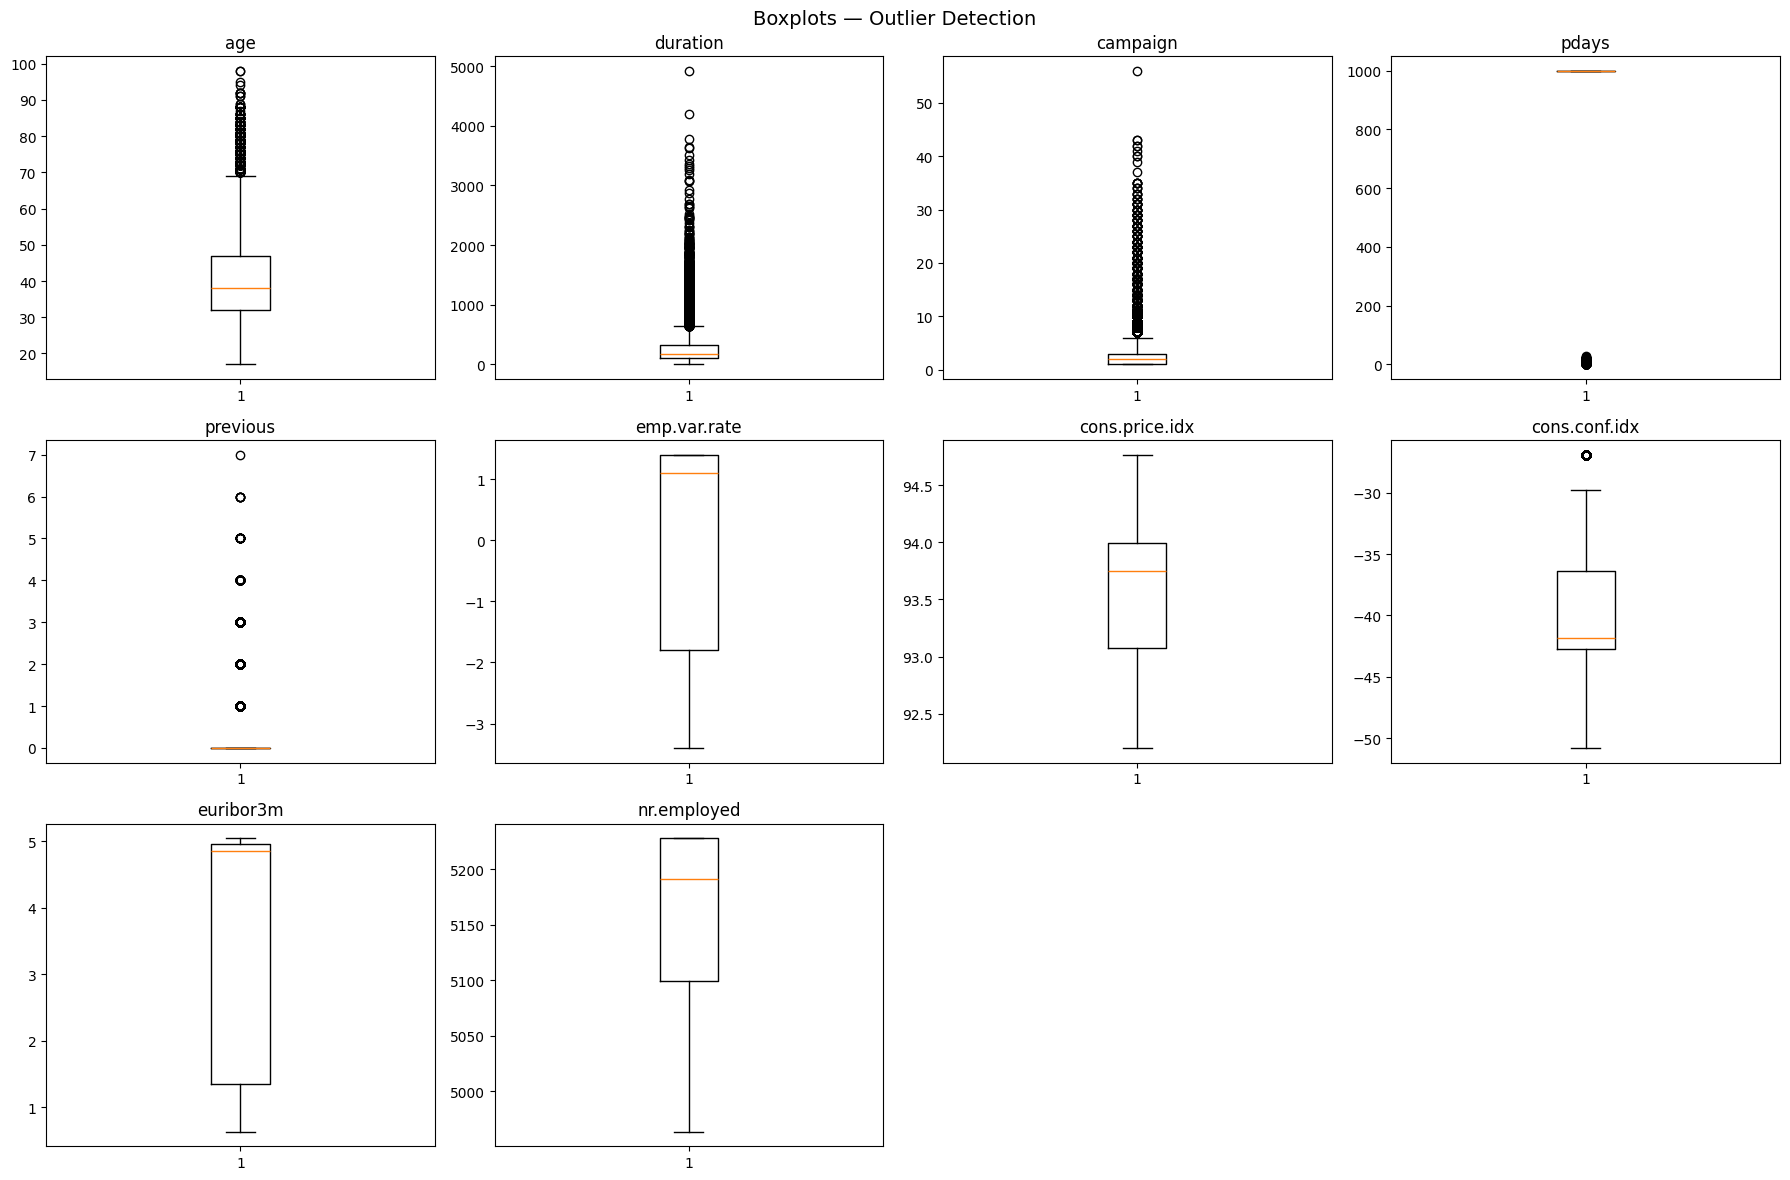

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

# Boxplots to detect outliers
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        axes[i].boxplot(df[col], vert=True)
        axes[i].set_title(col)
# hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()


In [11]:
df_prep = df.drop(columns=['y', 'duration'])

print(f"Shape before handling unknowns: {df_prep.shape}")

# Handle 'unknown' values: replace with mode of each column
for col in df_prep.select_dtypes(include='object').columns:
    if (df_prep[col] == 'unknown').any():
        mode_val = df_prep[col][df_prep[col] != 'unknown'].mode()[0]
        df_prep[col] = df_prep[col].replace('unknown', mode_val)

print(f"Unknowns remaining: {df_prep.isin(['unknown']).sum().sum()}")
print(f"Shape after dropping columns: {df_prep.shape}")

Shape before handling unknowns: (41188, 19)
Unknowns remaining: 0
Shape after dropping columns: (41188, 19)


In [12]:
cat_cols = df_prep.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"All numeric: {df_encoded.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all()}")
df_encoded.head()


Shape after encoding: (41188, 46)
All numeric: False


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,...,True,False,False,False,True,False,False,False,True,False


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f"Final shape: {X_scaled.shape}")
print(f"Any NaNs: {np.isnan(X_scaled).any()}")
print(f"Mean ≈ 0: {X_scaled.mean(axis=0).round(2)[:5]}")  # quick sanity check
print(f"Std  ≈ 1: {X_scaled.std(axis=0).round(2)[:5]}")


Final shape: (41188, 46)
Any NaNs: False
Mean ≈ 0: [-0. -0. -0.  0.  0.]
Std  ≈ 1: [1. 1. 1. 1. 1.]


In [15]:
km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df_encoded['Cluster'] = labels

print("--- Cluster Sizes ---")
print(pd.Series(labels).value_counts().sort_index())


--- Cluster Sizes ---
0    12208
1    15432
2    13548
Name: count, dtype: int64


In [16]:
cluster_summary = df_encoded.groupby('Cluster').mean()
print("--- Cluster Means (sample of first 10 features) ---")
cluster_summary.iloc[:, :10]


--- Cluster Means (sample of first 10 features) ---


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar
Cluster,,,,,,,,,,
0,40.305210,2.808159,999.000000,0.000082,1.201245,94.161596,-38.358077,4.884581,5204.336337,0.296609
1,40.105495,2.795425,999.000000,0.044842,1.052216,93.592675,-40.325194,4.766398,5220.611055,0.184163
2,39.677960,2.091305,887.959773,0.474683,-2.032027,93.028309,-42.637090,1.178603,5072.399417,0.206008


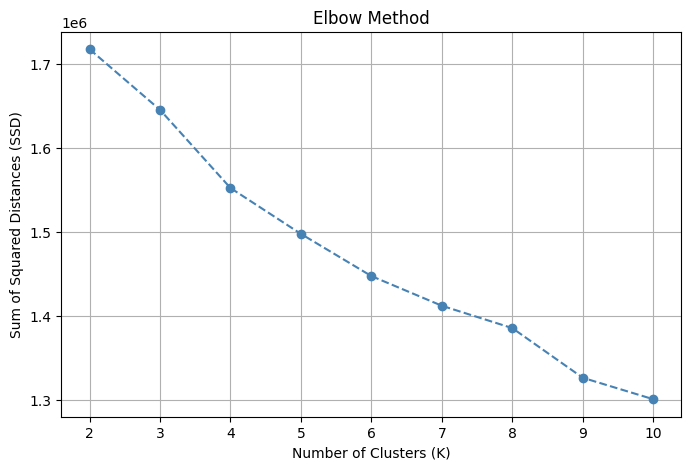

In [17]:
ssd = []
K_range = range(2, 11)

for k in K_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km_temp.fit(X_scaled)
    ssd.append(km_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, ssd, 'o--', color='steelblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()


K=2: Silhouette Score = 0.1372
K=3: Silhouette Score = 0.0571
K=4: Silhouette Score = 0.0761
K=5: Silhouette Score = 0.0882
K=6: Silhouette Score = 0.0989
K=7: Silhouette Score = 0.1044
K=8: Silhouette Score = 0.0921
K=9: Silhouette Score = 0.1189
K=10: Silhouette Score = 0.1149


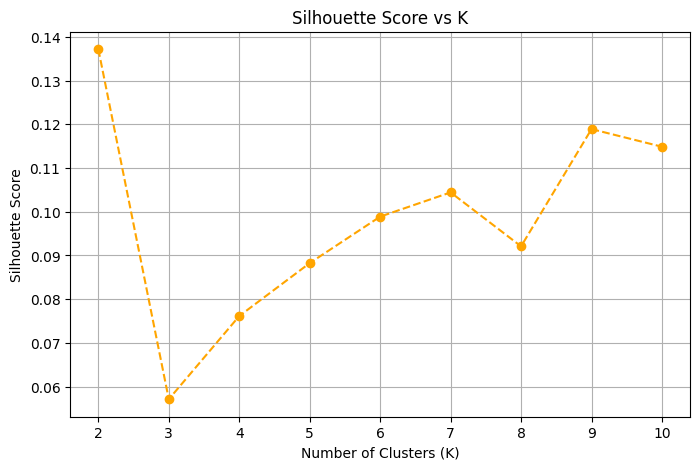


Best K by Silhouette Score: 2


In [19]:
sil_scores = []

for k in K_range:
    km_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    temp_labels = km_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, temp_labels)
    sil_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

# Identify best K
best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette Score: {best_k}")


In [20]:
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
final_labels = km_final.fit_predict(X_scaled)

print(f"--- Final Clustering with K={best_k} ---")
print(pd.Series(final_labels).value_counts().sort_index())


--- Final Clustering with K=2 ---
0    26959
1    14229
Name: count, dtype: int64
